In [1]:
# --- CELL 1: Setup & Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set style for plots
sns.set_style('whitegrid')
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [2]:
# --- CELL 2: Data Preparation ---
# NOTE: Replace this synthetic generation block with your actual image loading 
# logic (using cv2 or PIL) once you download a real dataset.

print("Generating synthetic multi-modal dataset for training demonstration...")
num_samples = 2000

# 1. Image Data (Simulating 36x36 Grayscale X-Rays)
X_images = np.random.rand(num_samples, 36, 36, 1)

# 2. Metadata (Simulating Age and Body Temperature)
ages = np.random.uniform(5, 90, num_samples) # Ages 5 to 90
temps = np.random.uniform(36.0, 41.0, num_samples) # Temp 36.0C to 41.0C
X_meta = np.column_stack((ages, temps))

# 3. Target Labels (0=Normal, 1=Pneumonia, 2=COVID-19, 3=Tuberculosis)
y_labels = np.random.randint(0, 4, num_samples)

# 4. Train/Test Split
X_img_train, X_img_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_images, X_meta, y_labels, test_size=0.2, random_state=42
)

print(f"Training Images Shape: {X_img_train.shape}")
print(f"Training Metadata Shape: {X_meta_train.shape}")
print(f"Training Labels Shape: {y_train.shape}")

Generating synthetic multi-modal dataset for training demonstration...
Training Images Shape: (1600, 36, 36, 1)
Training Metadata Shape: (1600, 2)
Training Labels Shape: (1600,)


In [3]:
# --- CELL 3: The Neural Network ---

# Branch 1: Convolutional Network for X-Ray Images
image_input = Input(shape=(36, 36, 1), name='image_input')
x = Conv2D(32, (3, 3), activation='relu', padding='same')(image_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
image_features = Dropout(0.3)(x) # Prevent overfitting

# Branch 2: Dense Network for Patient Vitals (Age, Temp)
meta_input = Input(shape=(2,), name='meta_input') 
y = Dense(32, activation='relu')(meta_input)
y = Dense(16, activation='relu')(y)
meta_features = Dropout(0.2)(y)

# Merge Branches
combined = Concatenate()([image_features, meta_features])

# Final Classification Layers
z = Dense(64, activation='relu')(combined)
z = Dropout(0.2)(z)
output = Dense(4, activation='softmax', name='disease_output')(z)

# Compile Model
model = Model(inputs=[image_input, meta_input], outputs=output)
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 36, 36, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 36, 36, 32)        │             320 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 18, 18, 32)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 18, 18, 64)        │          18,496 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 9, 9, 64)          │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 9, 9, 128)         │          73,856 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 4, 4, 128)         │               0 │ conv2d_2[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ meta_input (InputLayer)       │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 2048)              │               0 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │              96 │ meta_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         262,272 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 16)                │             528 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 16)                │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 144)               │               0 │ dropout[0][0],             │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 64)                │           9,28

 Total params: 365,108 (1.39 MB)

 Trainable params: 365,108 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# --- CELL 4: Model Training ---

# Add callbacks for smarter training
early_stop = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=3, min_lr=0.00001, monitor='val_loss')

print("Starting Model Training...")
history = model.fit(
    x=[X_img_train, X_meta_train], 
    y=y_train,
    validation_data=([X_img_test, X_meta_test], y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Starting Model Training...
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - accuracy: 0.2469 - loss: 2.1537 - val_accuracy: 0.2350 - val_loss: 1.4450 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - accuracy: 0.2713 - loss: 1.4989 - val_accuracy: 0.2600 - val_loss: 1.3940 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step - accuracy: 0.2556 - loss: 1.4116 - val_accuracy: 0.2525 - val_loss: 1.3900 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.2612 - loss: 1.3960 - val_accuracy: 0.2350 - val_loss: 1.3930 - learning_rate: 0.0010
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 278ms/step - accuracy: 0.2506 - loss: 1.3921 - val_accuracy: 0.2625 - val_loss: 1.3908 - learning_rate: 0.0010
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.2625 - loss: 1.3855 - val_accuracy: 0.2825 - val_loss: 1.3893 - learning_rate: 0.0010
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - a

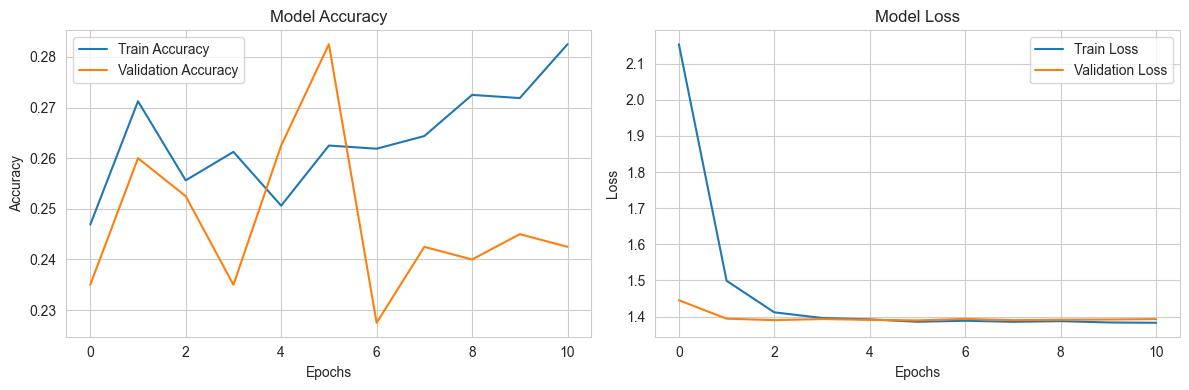

In [5]:
# --- CELL 5: Plotting Accuracy & Loss ---
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 345ms/step
Classification Report:
                     precision    recall  f1-score   support

             Normal       0.24      0.11      0.15        98
Bacterial Pneumonia       0.33      0.24      0.28       106
           COVID-19       0.25      0.16      0.19        94
       Tuberculosis       0.28      0.61      0.39       102

           accuracy                           0.28       400
          macro avg       0.28      0.28      0.25       400
       weighted avg       0.28      0.28      0.25       400



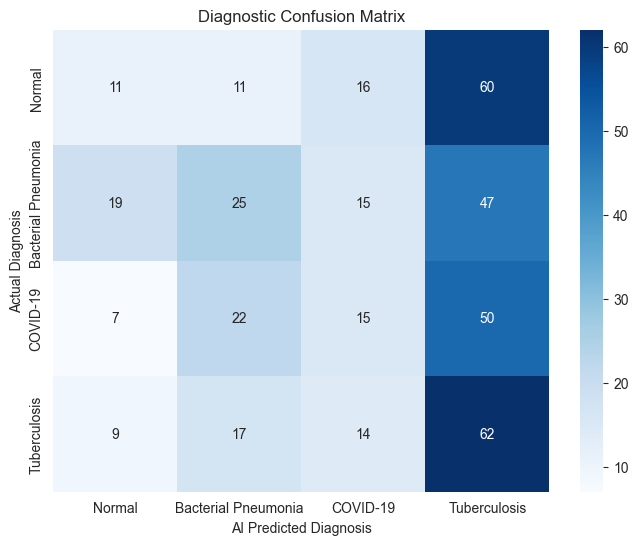

In [6]:
# --- CELL 6: Model Evaluation ---
predictions = model.predict([X_img_test, X_meta_test])
predicted_classes = np.argmax(predictions, axis=1)

classes = ["Normal", "Bacterial Pneumonia", "COVID-19", "Tuberculosis"]

print("Classification Report:")
print(classification_report(y_test, predicted_classes, target_names=classes))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Diagnostic Confusion Matrix')
plt.ylabel('Actual Diagnosis')
plt.xlabel('AI Predicted Diagnosis')
plt.show()

In [7]:
# --- CELL 7: Save the Model ---
# Save as .h5 file for the Streamlit dashboard
model_path = 'pneumonia_v2.h5'
model.save(model_path)
print(f"Model successfully saved to {model_path}!")
print("You can now move this file to your 'models/' folder to use in the web app.")

Model successfully saved to pneumonia_v2.h5!
You can now move this file to your 'models/' folder to use in the web app.
